# 14 · YAML Style Customization

**Where this sits in PyTex.** Every plot in these tutorials — XRD, SAED, pole figures,
crystal scenes — is drawn through a single, YAML-driven style system. Rather than
scattering colours and font sizes through plotting calls, PyTex resolves a **style
dictionary** from a named theme, an optional YAML file, and inline overrides, then hands
it to the renderers. This notebook shows how that layering works so you can produce
consistent, publication- or presentation-ready figures without editing library code.

## Learning goals

1. list the built-in themes and inspect a resolved style dictionary;
2. understand the **three-layer precedence**: theme → YAML file → inline overrides;
3. author a small YAML style file and merge it;
4. render the *same* data under two themes to see the effect.

## The resolution model

`resolve_style(theme=..., style_path=..., overrides=...)` deep-merges three sources,
later ones winning:

1. **theme** — a named base (`base`, `journal`, `dark`, `presentation`);
2. **style_path** — a user YAML file overriding selected keys;
3. **overrides** — an inline dict for last-mile tweaks.

Keys not mentioned by a higher layer keep the value from below, so a one-line override
never discards the rest of the theme. This is the same mechanism every `plot_*(theme=...,
style_path=..., style_overrides=...)` call uses internally.

In [1]:
from __future__ import annotations

import tempfile
import warnings
from pathlib import Path

warnings.filterwarnings("ignore", message="Issues encountered while parsing CIF")
warnings.filterwarnings("ignore", message="No _symmetry_equiv_pos_as_xyz")

from pytex import (
    FrameDomain,
    RadiationSpec,
    ReferenceFrame,
    generate_xrd_pattern,
    get_phase_fixture,
    list_style_themes,
    plot_xrd_pattern,
    resolve_style,
)

crystal = ReferenceFrame("crystal", FrameDomain.CRYSTAL, ("a", "b", "c"))

## 1 · Themes and the resolved dictionary

A resolved style is a nested dict keyed by plot family (`xrd`, `saed`, `crystal`,
`spherical`) plus a shared `common` block. Different themes set different values — for
example the XRD line colour differs between `journal` and `presentation`.

In [2]:
print("available themes:", list_style_themes())

journal = resolve_style(theme="journal")
presentation = resolve_style(theme="presentation")
print("\nstyle families:", list(journal.keys()))
print("journal      xrd.line_color:", journal["xrd"]["line_color"])
print("presentation xrd.line_color:", presentation["xrd"]["line_color"])
assert journal["xrd"]["line_color"] != presentation["xrd"]["line_color"]

available themes: ('base', 'dark', 'journal', 'presentation')

style families: ['common', 'xrd', 'saed', 'crystal', 'spherical']
journal      xrd.line_color: #0f172a
presentation xrd.line_color: #0f4c81


## 2 · Layering a YAML file and inline overrides

We write a tiny YAML file that recolours the XRD line and a SAED spot, then resolve it
on top of the `journal` theme with an inline override that turns off peak annotation.
The result shows the precedence at work:

- `xrd.line_color` comes from the **YAML file**;
- `xrd.annotate_peaks` comes from the **inline override**;
- `saed.spot_color` comes from the **YAML file**;
- `xrd.peak_color`, untouched by any higher layer, is **inherited from the theme**.

In [3]:
tmp = Path(tempfile.mkdtemp()) / "custom_style.yaml"
tmp.write_text(
    'xrd:\n'
    '  line_color: "#123456"\n'
    'saed:\n'
    '  spot_color: "#fde68a"\n',
    encoding="utf-8",
)

merged = resolve_style(
    theme="journal",
    style_path=tmp,
    overrides={"xrd": {"annotate_peaks": False}},
)
print("xrd.line_color   (from YAML file)   :", merged["xrd"]["line_color"])
print("xrd.annotate_peaks (from override)  :", merged["xrd"]["annotate_peaks"])
print("saed.spot_color  (from YAML file)   :", merged["saed"]["spot_color"])
print("xrd.peak_color   (inherited theme)  :", merged["xrd"]["peak_color"])

assert merged["xrd"]["line_color"] == "#123456"        # file layer
assert merged["xrd"]["annotate_peaks"] is False         # override layer
assert merged["saed"]["spot_color"] == "#fde68a"        # file layer
assert merged["xrd"]["peak_color"] == journal["xrd"]["peak_color"]  # inherited

xrd.line_color   (from YAML file)   : #123456
xrd.annotate_peaks (from override)  : False
saed.spot_color  (from YAML file)   : #fde68a
xrd.peak_color   (inherited theme)  : #b45309


## 3 · The same pattern, two themes

Style is separated from data: we generate one XRD pattern and render it under `journal`
and `dark` by passing only `theme=`. No plotting code changes — just the theme name.

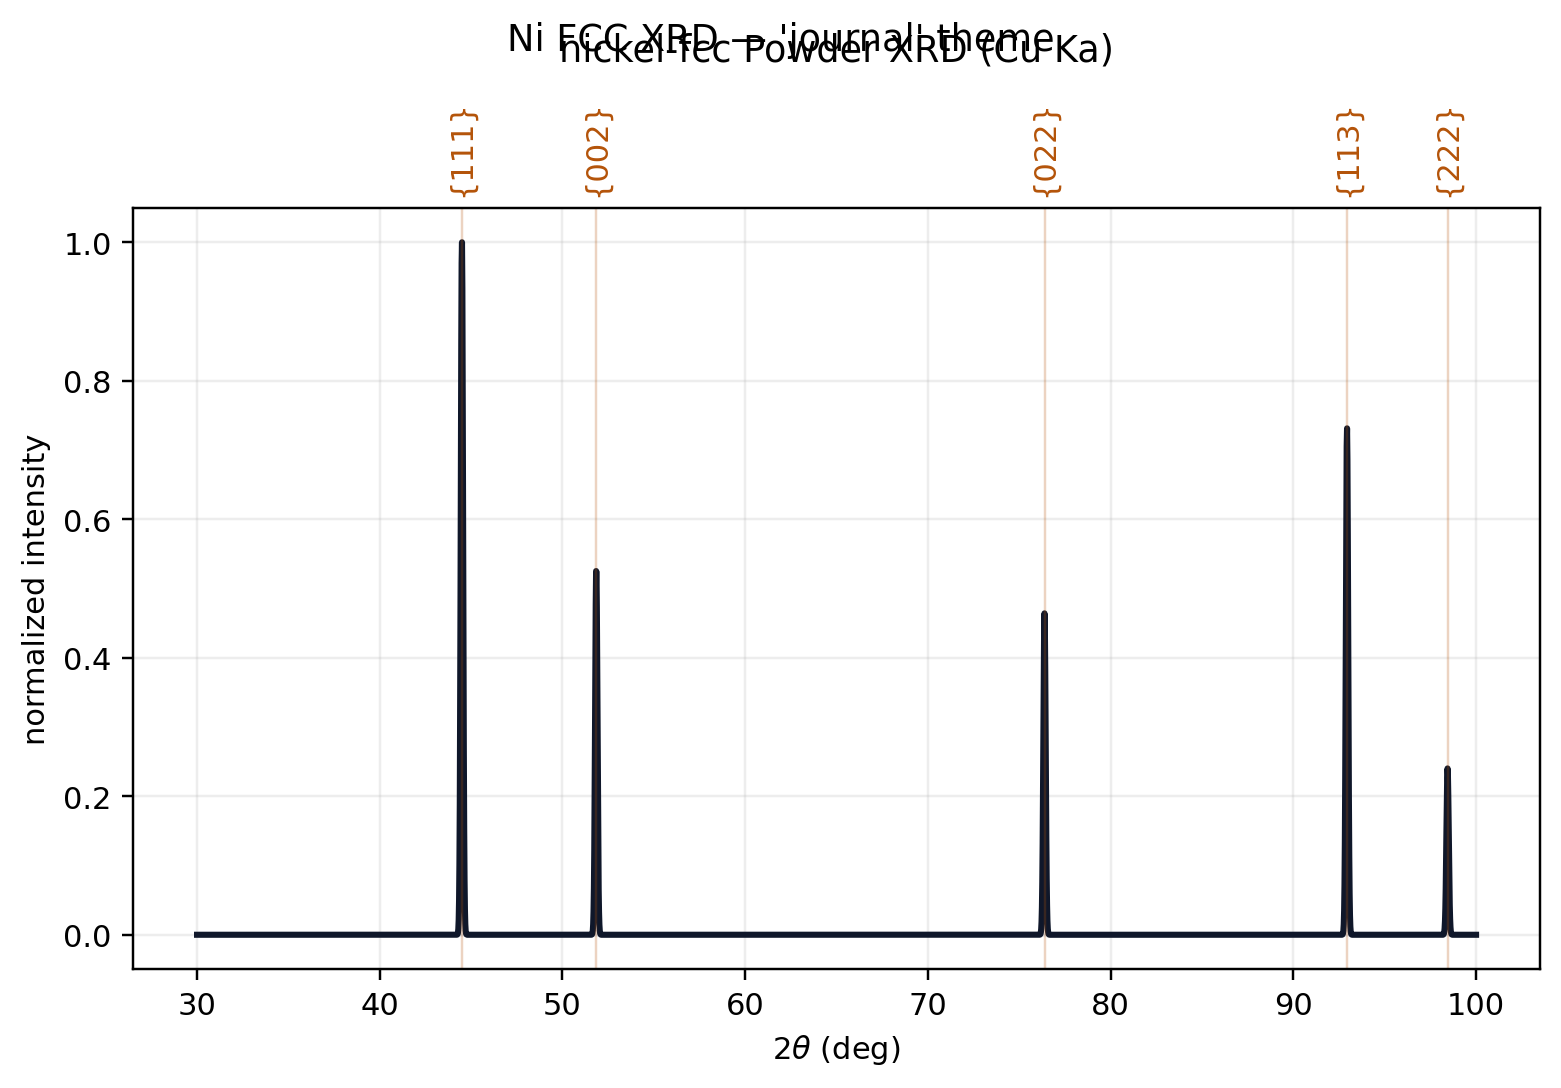

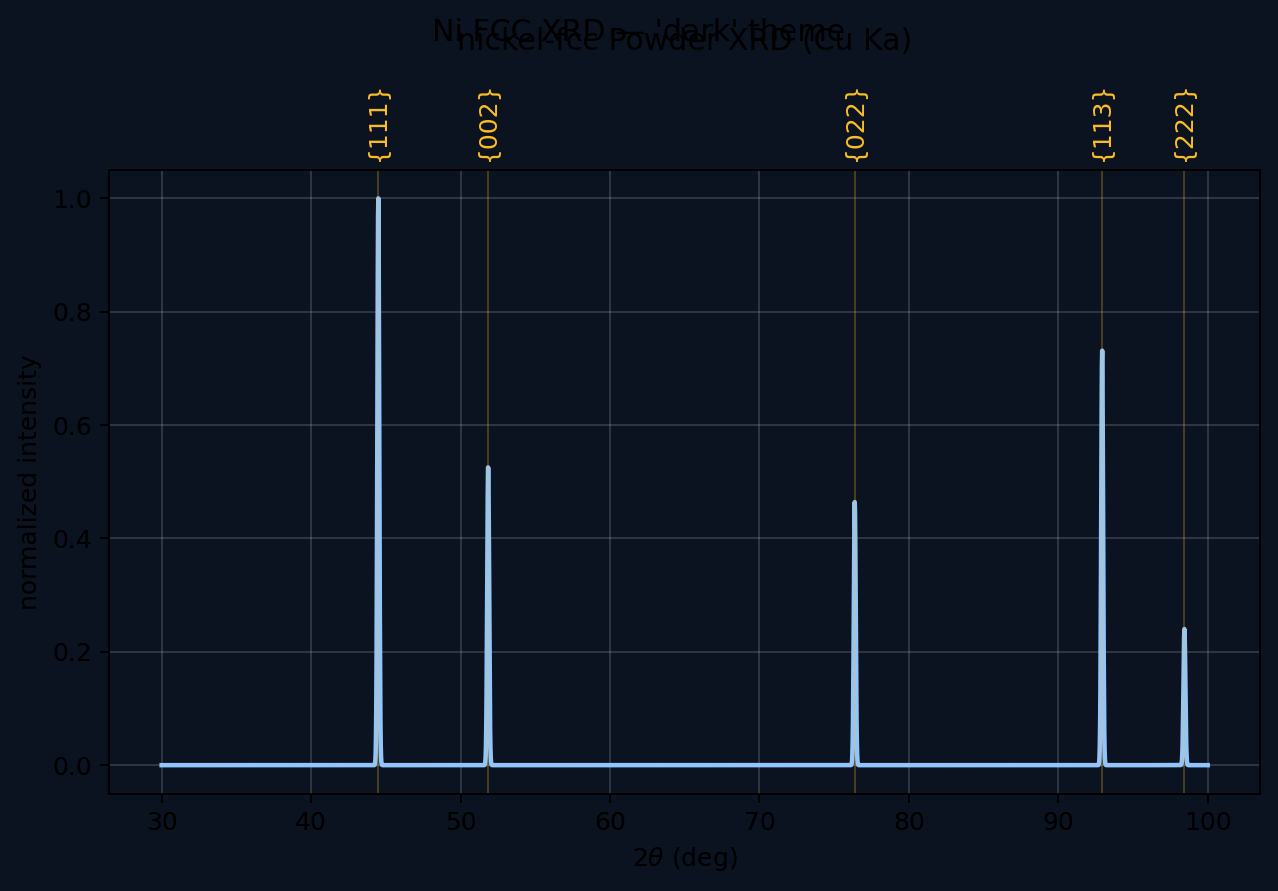

In [4]:
import matplotlib.pyplot as plt

nickel = get_phase_fixture("ni_fcc").load_phase(crystal_frame=crystal)
pattern = generate_xrd_pattern(nickel, radiation=RadiationSpec.cu_ka(),
                               two_theta_range_deg=(30.0, 100.0), max_index=6)

for theme in ("journal", "dark"):
    plot_xrd_pattern(pattern, theme=theme)
    plt.gcf().suptitle(f"Ni FCC XRD — '{theme}' theme")


## Summary and where to go next

- `resolve_style` deep-merges **theme → YAML file → inline overrides**, later layers
  winning and untouched keys inherited.
- Every `plot_*` accepts `theme=`, `style_path=`, and `style_overrides=`, so figures are
  restyled without touching plotting logic.
- Separating style from data lets one dataset render consistently across journal, dark,
  and presentation contexts.

**Next:** apply these themes across the pipeline in
[Notebook 15](15_structure_diffraction_visualization_pipeline.ipynb); the plotting
surfaces themselves are covered in
[Notebook 10](10_plotting_semantic_primitives.ipynb).